<a href="https://colab.research.google.com/github/selenakdik/bitki-sagligi-teshisi/blob/main/Bitki_Hastalik.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!unzip -q "/content/drive/MyDrive/bitki_veriseti.zip" -d "/content/dataset"

In [3]:
import os
print("Dosyalar başarıyla çıkarıldı. Ana klasörler:", os.listdir('/content/dataset'))

Dosyalar başarıyla çıkarıldı. Ana klasörler: ['plantvillage dataset']


In [6]:
import os
alt_klasorler = os.listdir('/content/dataset/plantvillage dataset')
print("Alt klasörler:", alt_klasorler)

Alt klasörler: ['color']


In [7]:
import os
color_path = '/content/dataset/plantvillage dataset/color'

# Klasörleri (sınıfları) listele ve alfabetik sırala
classes = sorted(os.listdir(color_path))

print(f"Toplam Sınıf Sayısı: {len(classes)}\n")
print(f"{'Hastalık Adı':<50} | {'Fotoğraf Sayısı'}")
print("-" * 70)

total_images = 0
for cls in classes:
    # Her bir hastalık klasörünün yolunu oluştur
    class_path = os.path.join(color_path, cls)
    # İçindeki dosya sayısını say
    num_images = len(os.listdir(class_path))
    total_images += num_images
    print(f"{cls:<50} | {num_images}")

print("-" * 70)
print(f"Toplam Renkli Fotoğraf Sayısı: {total_images}")

Toplam Sınıf Sayısı: 38

Hastalık Adı                                       | Fotoğraf Sayısı
----------------------------------------------------------------------
Apple___Apple_scab                                 | 630
Apple___Black_rot                                  | 621
Apple___Cedar_apple_rust                           | 275
Apple___healthy                                    | 1645
Blueberry___healthy                                | 1502
Cherry_(including_sour)___Powdery_mildew           | 1052
Cherry_(including_sour)___healthy                  | 854
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot | 513
Corn_(maize)___Common_rust_                        | 1192
Corn_(maize)___Northern_Leaf_Blight                | 985
Corn_(maize)___healthy                             | 1162
Grape___Black_rot                                  | 1180
Grape___Esca_(Black_Measles)                       | 1383
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)         | 1076
Grape___healthy              

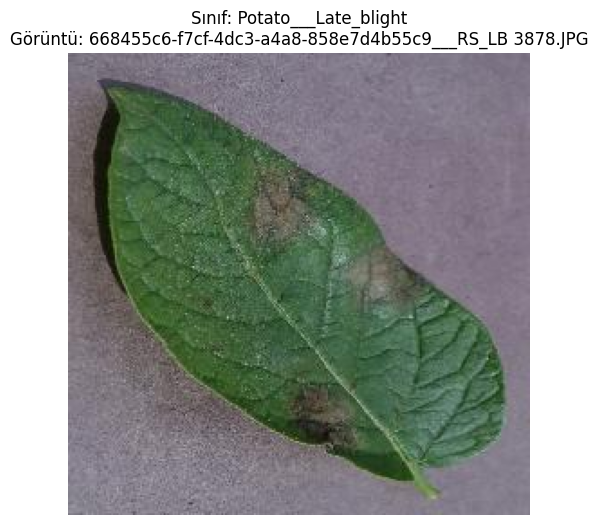

Görselin boyutu: (256, 256, 3)


In [8]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

# Rastgele bir sınıf seçme
random_class = random.choice(classes)
class_path = os.path.join(color_path, random_class)

# O sınıftan rastgele bir fotoğraf seçme
random_image = random.choice(os.listdir(class_path))
image_path = os.path.join(class_path, random_image)

img = mpimg.imread(image_path)
plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.title(f"Sınıf: {random_class}\nGörüntü: {random_image}")
plt.axis('off')
plt.show()

print(f"Görselin boyutu: {img.shape}")

In [9]:
import tensorflow as tf
from tensorflow.keras import layers

# Veri artırma katmanlarını tanımlıyoruz
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"), # Hem yatay hem dikey çevir
  layers.RandomRotation(0.2), # %20 oranında rastgele döndür
  layers.RandomZoom(0.1),    # %10 oranında rastgele yakınlaştır
])

In [10]:
# Görüntü boyutlarını ve paket miktarını belirleme
IMAGE_SIZE = (256, 256)
BATCH_SIZE = 32
color_path = '/content/dataset/plantvillage dataset/color'

# Eğitim verileri (%80)
train_ds = tf.keras.utils.image_dataset_from_directory(
    color_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

# Doğrulama verileri (%20)
val_ds = tf.keras.utils.image_dataset_from_directory(
    color_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

Found 54305 files belonging to 38 classes.
Using 43444 files for training.
Found 54305 files belonging to 38 classes.
Using 10861 files for validation.


In [11]:
import numpy as np
import os

# Sınıf isimlerini veri yükleyicimizden al
class_names = train_ds.class_names

# Her sınıfın ağırlığını hesaplama
class_weights = {}
total_images = 54305
n_classes = 38

for i, name in enumerate(class_names):
    # O sınıfın klasöründeki dosya sayısını bul
    class_count = len(os.listdir(os.path.join(color_path, name)))

    # Formül: Toplam / (Sınıf Sayısı * Sınıftaki Veri Sayısı)
    # Bu sayede az verisi olan sınıfın ağırlığı yüksek çıkar.
    weight = total_images / (n_classes * class_count)
    class_weights[i] = weight

print("Sınıf ağırlıkları başarıyla hesaplandı!")
# Örnek olarak ilk 3 sınıfın ağırlığına bakarsak:
for i in range(3):
    print(f"{class_names[i]}: {class_weights[i]:.2f}")

Sınıf ağırlıkları başarıyla hesaplandı!
Apple___Apple_scab: 2.27
Apple___Black_rot: 2.30
Apple___Cedar_apple_rust: 5.20


In [12]:

import tensorflow as tf

# HİPERPARAMETRE: Öğrenme hızı ayarı
ogrenme_hizi = 0.001
optimizasyon_araci = tf.keras.optimizers.Adam(learning_rate=ogrenme_hizi)

# EARLYSTOPPING
erken_durdurma = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

print("EarlyStopping ve Hiperparametre başarıyla tanımlandı!")


EarlyStopping ve Hiperparametre başarıyla tanımlandı!


In [13]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Veri artırma katmanını tanımlama
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2),
  layers.RandomZoom(0.1),
])

# Modeli kuralım
model = models.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(256, 256, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'), # Nöron sayısı

    # OVERFITTING önlemi
    layers.Dropout(0.5),

    layers.Dense(38, activation='softmax')
])

# Modeli derleme
model.compile(
    optimizer=optimizasyon_araci,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(), #hata payını ölçme
    metrics=['accuracy'] # başarıyı doğruluk yüzdesine göre ayarlama
)

print("Güncel model mimarisi oluşturuldu ve derlendi!")

Güncel model mimarisi oluşturuldu ve derlendi!


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
# Eğitimi başlatma
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[erken_durdurma],
    class_weight=class_weights
)

Epoch 1/100
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 116s 79ms/step - accuracy: 0.2722 - loss: 2.6911 - val_accuracy: 0.5473 - val_loss: 1.5355
Epoch 2/100
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 107s 79ms/step - accuracy: 0.5326 - loss: 1.5848 - val_accuracy: 0.6926 - val_loss: 0.9923
Epoch 3/100
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 105s 77ms/step - accuracy: 0.6239 - loss: 1.2556 - val_accuracy: 0.7073 - val_loss: 0.9595
Epoch 4/100
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 106s 78ms/step - accuracy: 0.6838 - loss: 1.0503 - val_accuracy: 0.7944 - val_loss: 0.6461
Epoch 5/100
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 105s 77ms/step - accuracy: 0.7118 - loss: 0.9397 - val_accuracy: 0.8045 - val_loss: 0.6301
Epoch 6/100
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 108s 79ms/step - accuracy: 0.7423 - loss: 0.8332 - val_accuracy: 0.8378 - val_loss: 0.5126
Epoch 7/100
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 105s 77ms/step - accuracy: 0.7714 - loss: 0.7339 - val_accuracy: 0.8401 - val_loss: 0.5030
Epoch 8/100
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 106s 78ms/step - ac

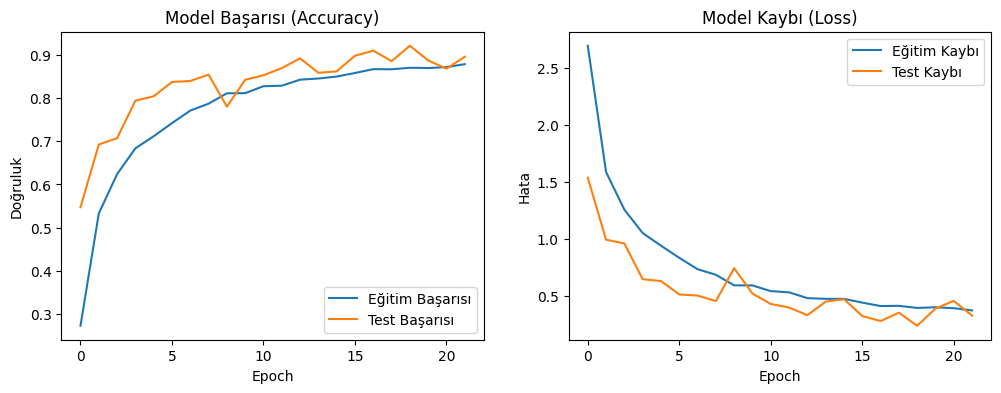

In [15]:
import matplotlib.pyplot as plt

# Doğruluk (Accuracy) Grafiği
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Eğitim Başarısı')
plt.plot(history.history['val_accuracy'], label='Test Başarısı')
plt.title('Model Başarısı (Accuracy)')
plt.xlabel('Epoch')
plt.ylabel('Doğruluk')
plt.legend()

# Kayıp (Loss) Grafiği
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Eğitim Kaybı')
plt.plot(history.history['val_loss'], label='Test Kaybı')
plt.title('Model Kaybı (Loss)')
plt.xlabel('Epoch')
plt.ylabel('Hata')
plt.legend()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step


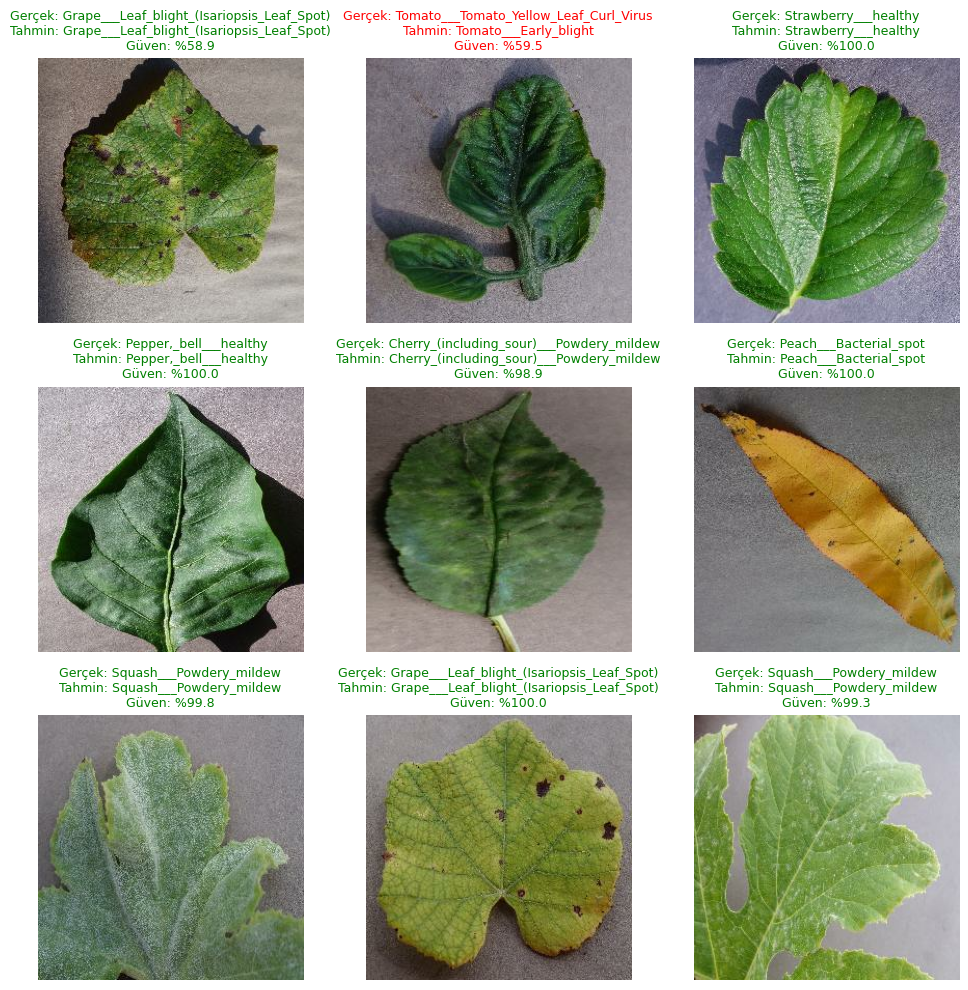

In [16]:
import numpy as np
import random

# Doğrulama setinden bir paket (batch) resim alıyoruz
image_batch, label_batch = next(iter(val_ds))

# Modelin tahminlerini alalım
predictions = model.predict(image_batch)

# Rastgele 9 tane benzersiz indeks seçiyoruz (0 ile 31 arası) (batch size 32)
random_indices = random.sample(range(len(image_batch)), 9)

plt.figure(figsize=(10, 10))

for i, idx in enumerate(random_indices):
    ax = plt.subplot(3, 3, i + 1)

    # Seçilen rastgele indeksteki resmi göster
    plt.imshow(image_batch[idx].numpy().astype("uint8"))

    actual_label = class_names[label_batch[idx]]
    predicted_label = class_names[np.argmax(predictions[idx])]
    confidence = 100 * np.max(predictions[idx])

    color = "green" if actual_label == predicted_label else "red"


    plt.title(f"Gerçek: {actual_label}\nTahmin: {predicted_label}\nGüven: %{confidence:.1f}",
              color=color, fontsize=9)

    plt.axis("off")

plt.tight_layout()
plt.show()


In [17]:
import shutil
#Modeli Colab içine kaydetme
model.save('bitki_hastalik_modeli_v2.h5')
print("Model .h5 olarak kaydedildi! ✅")

Model .h5 olarak kaydedildi! ✅


In [18]:
import shutil
shutil.copy('bitki_hastalik_modeli_v2.h5', '/content/drive/MyDrive/bitki_hastalik_modeli_v2.h5')
print("Model Google Drive'a başarıyla yedeklendi! ☁️✅")

Model Google Drive'a başarıyla yedeklendi! ☁️✅


In [19]:
import tensorflow as tf

# TFLite dönüştürücüsünü hazırlama
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Dosyayı Colab'e yazma
tflite_dosya_adi = 'bitki_hastalik_modeli_v2.tflite'
with open(tflite_dosya_adi, 'wb') as f:
    f.write(tflite_model)

print(f"1. Adım Tamam: {tflite_dosya_adi} oluşturuldu! ✅")

Saved artifact at '/tmp/tmpjgx5jprd'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 38), dtype=tf.float32, name=None)
Captures:
  140007617122128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140007617130192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140007619530192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140007616551760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140007616553872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140007614804816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140007614801168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140007614793104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140007614803280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140007614796752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1400058494078

In [21]:
import shutil

# labels.txt dosyasını oluştur (Sınıf isimlerini içine yazar)
with open('labels.txt', 'w') as f:
    for name in class_names:
        f.write(f"{name}\n")
print("1. Adım: labels.txt başarıyla oluşturuldu! 🏷️")

# Tüm dosyaları Drive'a kopyalama
# .h5 yedeği
shutil.copy('bitki_hastalik_modeli_v2.h5', '/content/drive/MyDrive/bitki_hastalik_modeli_v2.h5')
# .tflite
shutil.copy('bitki_hastalik_modeli_v2.tflite', '/content/drive/MyDrive/bitki_hastalik_modeli_v2.tflite')
# labels.txt (İsim listesi)
shutil.copy('labels.txt', '/content/drive/MyDrive/labels.txt')

print("Tüm dosyalar (.h5, .tflite, .txt) Google Drive'a başarıyla kopyalandı!")

1. Adım: labels.txt başarıyla oluşturuldu! 🏷️
Tüm dosyalar (.h5, .tflite, .txt) Google Drive'a başarıyla kopyalandı!
